In [199]:
using Plots,JLD2,LinearAlgebra

In [200]:
Nx=20
Ny=20
tper=-0.37

tpa=2.0
tNNN=-0.08

α=-1.5
temp=0.01
β=0.15
K=1.0;
KNNN=0.0;
gshear=0.1
trytime_record=1

filling=1.25
#trytime=1

1.25

In [201]:
st=load("test.jld2")
   

Dict{String, Any} with 12 entries:
  "Eelec"          => -2.37906
  "spectrum"       => [-4.74013, -4.74013, -4.70392, -4.70392, -4.70392, -4.703…
  "max_record"     => 0.137313
  "average_record" => 0.0763235
  "orbital_id"     => [1 21 … 361 381; 2 22 … 362 382; … ; 19 39 … 379 399; 20 …
  "phonon_id"      => [1 21 … 361 381; 2 22 … 362 382; … ; 19 39 … 379 399; 20 …
  "phonon_coor"    => [-0.0519477, 0.0496721, -0.00635803, -0.0437019, 0.055414…
  "FL"             => 1.64448
  "ave_npa"        => 500.0
  "E_total"        => -2.37771
  "Egap"           => 0.0431258
  "free_energy"    => -2.37779

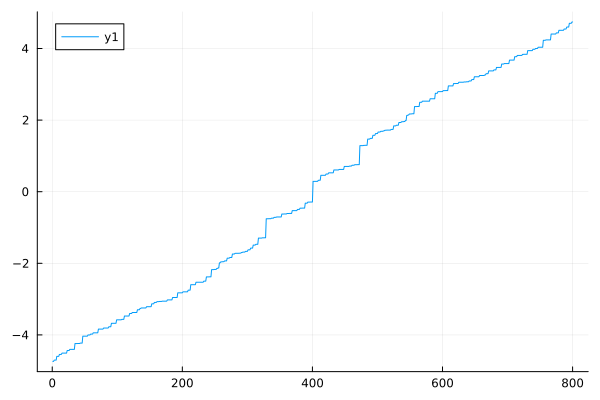

In [202]:
plot(sort(st["spectrum"]))

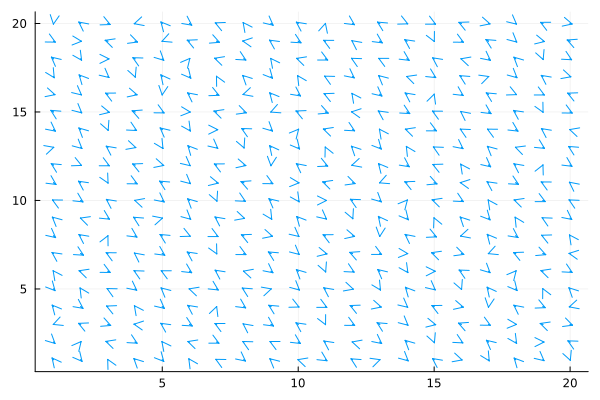

In [203]:
phonon_coor=st["phonon_coor"]
phonon_id=st["phonon_id"]
atom_x=zeros(Float64,Nx,Ny)
atom_y=zeros(Float64,Nx,Ny)
dis_x=zeros(Float64,Nx,Ny)
dis_y=zeros(Float64,Nx,Ny)

for ja in 1:Nx, jb in 1:Ny
    atom_x[ja,jb]=ja
    atom_y[ja,jb]=jb
    dis_x[ja,jb]=phonon_coor[phonon_id[ja,jb,1]]+ja
    dis_y[ja,jb]=phonon_coor[phonon_id[ja,jb,2]]+jb
    
end

dis_x=dis_x .- atom_x
dis_y=dis_y .- atom_y
p1=quiver(vec(atom_x),vec(atom_y),quiver=(vec(dis_x),vec(dis_y)))




In [204]:
#savefig(p1,"quiverplot.png")

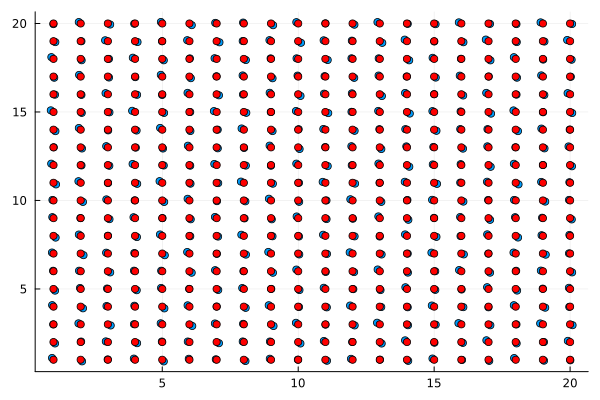

In [205]:
phonon_coor=st["phonon_coor"]
phonon_id=st["phonon_id"]
atom_x=zeros(Float64,Nx,Ny)
atom_y=zeros(Float64,Nx,Ny)
dis_x=zeros(Float64,Nx,Ny)
dis_y=zeros(Float64,Nx,Ny)

for ja in 1:Nx, jb in 1:Ny
    atom_x[ja,jb]=ja
    atom_y[ja,jb]=jb
    dis_x[ja,jb]=phonon_coor[phonon_id[ja,jb,1]]+ja
    dis_y[ja,jb]=phonon_coor[phonon_id[ja,jb,2]]+jb
    
end


p2=scatter(vec(dis_x),vec(dis_y))
scatter!(vec(atom_x),vec(atom_y),color=:red,legend=:false)

In [206]:
#savefig(p2,"atomplot.png")

In [207]:
sort(vec(dis_y)-vec(atom_y))

400-element Vector{Float64}:
 -0.09835661054601097
 -0.09826576409924925
 -0.09807759439842378
 -0.09793141828301088
 -0.09781558132520374
 -0.09520609910237343
 -0.09511479648659105
 -0.0949271074459519
 -0.09478021437274897
 -0.09466463720839613
  ⋮
  0.0983857194219997
  0.09857368750267659
  0.09871975757574702
  0.09883506768735373
  0.09883553073086038
  0.09892499225526308
  0.09911363780487648
  0.0992584118042048
  0.09937458327243442

In [208]:
sort(vec(sqrt.(dis_x.^2+dis_y.^2)))

400-element Vector{Float64}:
  1.4510917488741122
  2.1909865635123675
  2.2421186369682506
  2.858752395734932
  3.155025747104202
  3.1620880887216143
  3.5642659503144998
  3.6086316641870133
  4.097013186825073
  4.194224299656229
  ⋮
 26.16153828023275
 26.261183876892165
 26.26629733495711
 26.895807185355498
 26.89935838862271
 26.91614567989227
 27.555722147763156
 27.573997386267745
 28.315538061277326

In [209]:
sum(vec(sqrt.(dis_x.^2+dis_y.^2)))/(Nx*Ny)

15.95197269790786

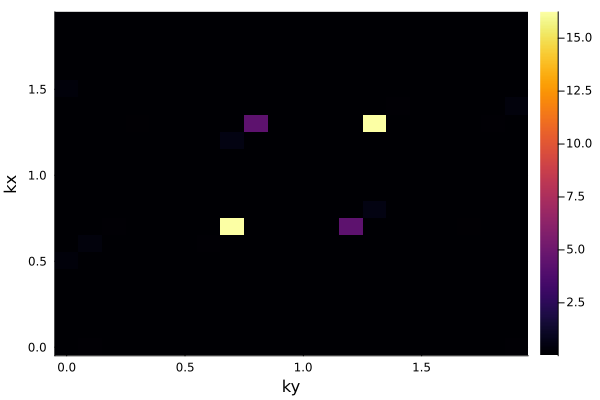

In [210]:
kx_space=2π*collect(0:1:Nx-1)/Nx
ky_space=2π*collect(0:1:Ny-1)/Ny
Fourier_mode_x=zeros(ComplexF64,length(kx_space),length(ky_space))
for ja in eachindex(kx_space), jb in eachindex(ky_space)
    kx=kx_space[ja]
    ky=ky_space[jb]
    for jc in 1:Nx, jd in 1:Ny, xp in -0:0, yp in -0:0
    Fourier_mode_x[ja,jb]+=phonon_coor[phonon_id[jc,jd,1]]*exp(-im*(kx*(jc+xp*Nx)+ky*(jd+yp*Ny)))
    end

end

heatmap(ky_space/pi,kx_space/pi,abs.(Fourier_mode_x),xlabel="ky",ylabel="kx")

In [211]:
sort(vec(abs.(Fourier_mode_x)))

400-element Vector{Float64}:
  7.494005416219807e-16
  3.2403807662528644e-15
  3.923335632385485e-15
  3.955186085825789e-15
  3.959698006696721e-15
  4.027629794863927e-15
  4.801832657016873e-15
  4.995012184155083e-15
  5.272844459025769e-15
  5.282071961389662e-15
  ⋮
  0.24592258091553598
  0.3080813715930868
  0.3080813715930921
  0.4936918774322147
  0.49369187743222676
  4.3075170357377095
  4.30751703573772
 16.24391133427786
 16.24391133427789

In [212]:
findmax(abs.(Fourier_mode_x))

(16.24391133427789, CartesianIndex(8, 8))

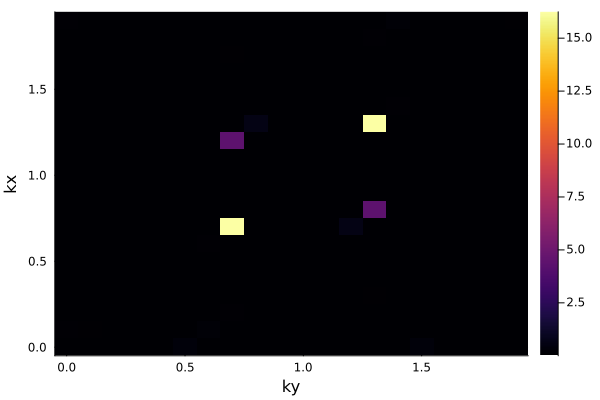

In [213]:
kx_space=2π*collect(0:1:Nx-1)/Nx
ky_space=2π*collect(0:1:Ny-1)/Ny
Fourier_mode_y=zeros(ComplexF64,length(kx_space),length(ky_space))
for ja in eachindex(kx_space), jb in eachindex(ky_space)
    kx=kx_space[ja]
    ky=ky_space[jb]
    for jc in 1:Nx, jd in 1:Ny, xp in -0:0, yp in -0:0
    Fourier_mode_y[ja,jb]+=phonon_coor[phonon_id[jc,jd,2]]*exp(-im*(kx*(jc+xp*Nx)+ky*(jd+yp*Ny)))
    end

end

heatmap(ky_space/pi,kx_space/pi,abs.(Fourier_mode_y),xlabel="ky",ylabel="kx")

In [214]:
findmax(abs.(Fourier_mode_y))

(16.243548835235238, CartesianIndex(8, 8))

In [215]:
Fourier_mode_y[8,14]

-8.58429108289982e-7 + 1.0509026609269504e-6im

In [216]:
Fourier_mode_x[8,14]

-2.1936465112448733e-7 + 7.397683352090937e-7im

In [217]:
Fourier_mode_y[14,8]

-8.584291147847867e-7 - 1.0509026544265273e-6im

In [218]:
Fourier_mode_x[14,8]

-2.193646470582955e-7 - 7.397683407016261e-7im

In [219]:
Fourier_mode_y[8,8]

-10.65906493503559 + 12.25712908773367im

In [220]:
Fourier_mode_x[8,8]

10.660040691635047 - 12.256760905254156im